In [17]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os
import qlbm
from qlbm.initial_conditions import *
from qlbm.visualization import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


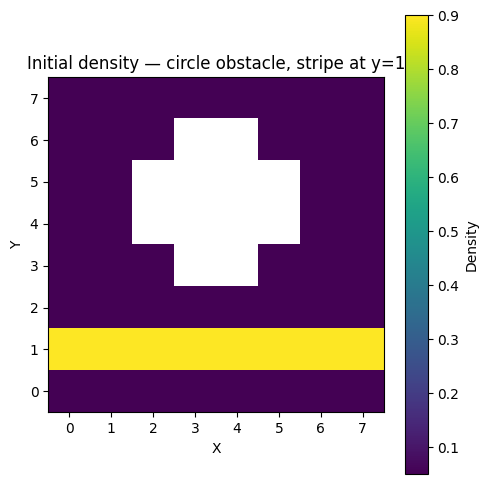

In [18]:
# ── Lattice ──────────────────────────────────────────────────────────
EXPERIMENT_NAME = "BoundaryConditions2D_CircleObstacle"
NUM_ITERATIONS  = 25

# D2Q5
links          = [[0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]]
weights        = [1/3, 1/6, 1/6, 1/6, 1/6]
speed_of_sound = 1 / np.sqrt(3)

# ── Grid ──────────────────────────────────────────────────────────────
GRID_SIZE = (8, 8)
Nx, Ny = GRID_SIZE

# ── Circular obstacle ─────────────────────────────────────────────────
cx, cy, radius = 3.5, 4.5, 2.0
wall_mask = np.array(
    [[(x - cx)**2 + (y - cy)**2 < radius**2 for y in range(Ny)]
     for x in range(Nx)],
    dtype=bool,
)

# ── Initial conditions ─────────────────────────────────────────────────
initial_density = np.full(GRID_SIZE, 0.05)
initial_density[:, 1] = 0.9       # horizontal stripe at y=1
initial_density[wall_mask] = 0.0  # zero inside obstacle

# ── Boundary conditions ────────────────────────────────────────────────
nv = len(links)
link_dirs    = {tuple(l): i for i, l in enumerate(links)}
stat_idx     = link_dirs[(0, 0)]
REFLECT_FRAC = 0.2

bc = np.zeros((Nx, Ny, nv, nv))
for x in range(Nx):
    for y in range(Ny):
        bc[x, y] = np.eye(nv)

for x in range(Nx):
    for y in range(Ny):
        if wall_mask[x, y]:
            continue
        # Collect links that point into a wall neighbour
        wall_links = []
        for link, idx in link_dirs.items():
            if link == (0, 0):
                continue
            nx_, ny_ = (x + link[0]) % Nx, (y + link[1]) % Ny
            if wall_mask[nx_, ny_]:
                opp = tuple(-v for v in link)
                wall_links.append((idx, link_dirs[opp]))

        if not wall_links:
            continue

        wall_in_set = {wl[0] for wl in wall_links}
        for perp_in, perp_out in wall_links:
            bc[x, y, perp_in, perp_in]  = 0.0
            bc[x, y, perp_out, perp_in] = REFLECT_FRAC
            safe = [t for t in range(nv)
                    if t not in (perp_in, perp_out, stat_idx) and t not in wall_in_set]
            if safe:
                frac = (1.0 - REFLECT_FRAC) / len(safe)
                for t in safe:
                    bc[x, y, t, perp_in] = frac
            else:
                bc[x, y, perp_out, perp_in] = 1.0

boundary_conditions = bc

# ── Velocity field ─────────────────────────────────────────────────────
velocity = np.zeros((2, *GRID_SIZE))
velocity[1, :, :] = 0.15   # uniform upward

config = [
    (NUM_ITERATIONS, velocity, links, weights, speed_of_sound, boundary_conditions),
]

# ── Sanity-check plot ──────────────────────────────────────────────────
display = initial_density.copy().astype(float)
display[wall_mask] = np.nan   # obstacle shown as blank

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(display.T, cmap='viridis', origin='lower')
plt.colorbar(im, ax=ax, label='Density')
ax.set_title('Initial density — circle obstacle, stripe at y=1')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.tight_layout(); plt.show()

In [19]:
timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
dirname    = f"experiments/{EXPERIMENT_NAME}_{timestamp}"
os.makedirs(dirname, exist_ok=True)

classical_csv = f"{dirname}/classical.csv"
quantum_csv   = f"{dirname}/quantum.csv"

qlbm.simulate_flow_classical(initial_density, config, classical_csv)
qlbm.simulate_flow(initial_density, config, quantum_csv)

Classical simulation: iterations 0-25/25
Classical Iteration 1/25
Classical Iteration 2/25
Classical Iteration 3/25
Classical Iteration 4/25
Classical Iteration 5/25
Classical Iteration 6/25
Classical Iteration 7/25
Classical Iteration 8/25
Classical Iteration 9/25
Classical Iteration 10/25
Classical Iteration 11/25
Classical Iteration 12/25
Classical Iteration 13/25
Classical Iteration 14/25
Classical Iteration 15/25
Classical Iteration 16/25
Classical Iteration 17/25
Classical Iteration 18/25
Classical Iteration 19/25
Classical Iteration 20/25
Classical Iteration 21/25
Classical Iteration 22/25
Classical Iteration 23/25
Classical Iteration 24/25
Classical Iteration 25/25
Classical simulation complete. Results saved to experiments/BoundaryConditions2D_CircleObstacle_20260421_184033/classical.csv
Pre-building all circuit components for 1 configuration(s)...
  Building components for configuration 1/1...
Using SVD decomposition for non-diagonal collision matrix
Decomposition complete
Ad

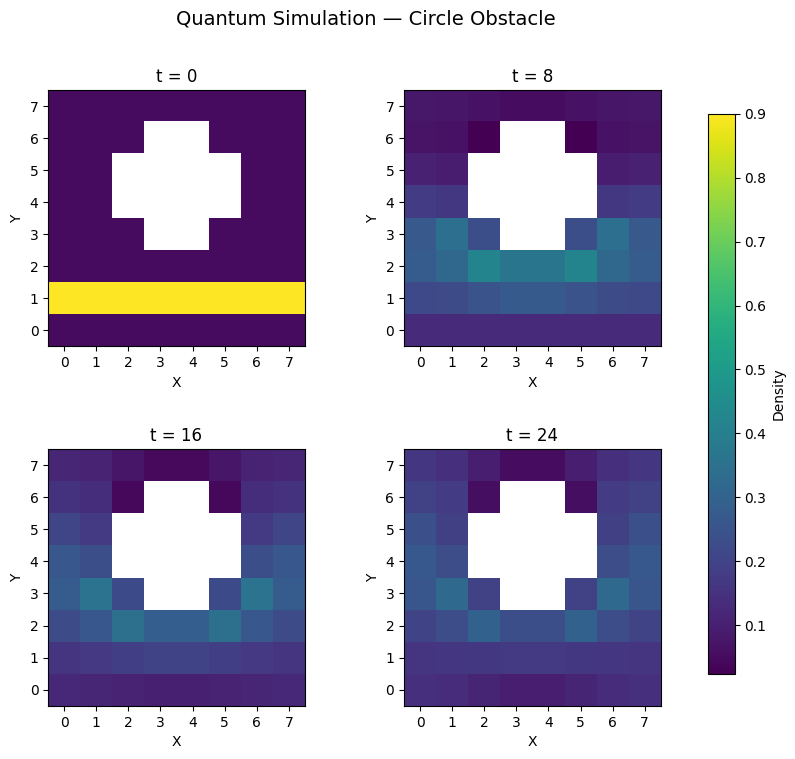

Snapshots saved to experiments/BoundaryConditions2D_CircleObstacle_20260421_184033/snapshots.png


In [24]:
snapshot_iters = np.linspace(0, NUM_ITERATIONS - 1, 4, dtype=int).tolist()

df_q = pd.read_csv(quantum_csv, header=None)

# Compute global vmin/vmax across all snapshots for a consistent colour scale
frames = []
for t in snapshot_iters:
    frame = df_q.iloc[t].values.reshape(GRID_SIZE, order='F').astype(float)
    frame[wall_mask] = np.nan
    frames.append(frame)

vmin = min(np.nanmin(f) for f in frames)
vmax = max(np.nanmax(f) for f in frames)

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
fig.suptitle('Quantum Simulation — Circle Obstacle', fontsize=14)

for idx, (t, frame) in enumerate(zip(snapshot_iters, frames)):
    ax = axes[idx // 2, idx % 2]
    im = ax.imshow(frame.T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f't = {t}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.set_xticks(range(Nx))
    ax.set_yticks(range(Ny))

fig.subplots_adjust(right=0.85, hspace=0.4)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Density')

plt.savefig(f"{dirname}/snapshots.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Snapshots saved to {dirname}/snapshots.png")

In [21]:
# RMSE between classical and quantum over time
qlbm.save_rmse_comparison(classical_csv, quantum_csv, GRID_SIZE, f"{dirname}/rmse.png")

RMSE comparison saved to experiments/BoundaryConditions2D_CircleObstacle_20260421_184033/rmse.png


In [22]:
# Animated classical result
animate_density_evolution(GRID_SIZE, classical_csv, interval=100, boundary_nodes=wall_mask)

In [23]:
# Animated quantum result
animate_density_evolution(GRID_SIZE, quantum_csv, interval=100, boundary_nodes=wall_mask)